In [375]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

import nltk
import re

from nltk import word_tokenize , sent_tokenize ,WordNetLemmatizer
lammmmmetize = WordNetLemmatizer()
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler , LabelEncoder , Normalizer , MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import classification_report , accuracy_score , f1_score , recall_score , confusion_matrix ,precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC



stop_words = set(stopwords.words('english'))


In [376]:
dataset = '../data/customer_support.csv'
df = pd.read_csv(dataset)

In [377]:
df.head(5)

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [378]:
df = df.drop(columns=['flags'])
df.head(5)

,instruction,category,intent,response
0,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [379]:
df.tail(5)

,instruction,category,intent,response
26867,I am waiting for a rebate of {{Refund Amount}}...,REFUND,track_refund,Thank you for sharing your situation regarding...
26868,how to see if there is anything wrong with my ...,REFUND,track_refund,Ensuring the accuracy of your restitution is o...
26869,I'm waiting for a reimbjrsement of {{Currency ...,REFUND,track_refund,"Firstly, I genuinely understand the importance..."
26870,I don't know what to do to see my reimbursemen...,REFUND,track_refund,I've understood you're unsure about how to che...
26871,I need to know if there is anything new on the...,REFUND,track_refund,It's completely understandable that you want t...


In [440]:
df.head(2500)

,instruction,category,intent,response,question_instruction,intent_original,intent_encoded
0,question about cancelling order {{Order Number}},6,cancel_order,I've understood you have a question regarding ...,question about canceling order order number,cancel_order,0
1,i have a question about cancelling oorder {{Or...,6,cancel_order,I've been informed that you have a question ab...,i have a question about canceling order order...,cancel_order,0
2,i need help cancelling puchase {{Order Number}},6,cancel_order,I can sense that you're seeking assistance wit...,i ned help canceling puchase order number,cancel_order,0
3,I need to cancel purchase {{Order Number}},6,cancel_order,I understood that you need assistance with can...,i ned to cancel purchase order number,cancel_order,0
4,"I cannot afford this order, cancel purchase {{...",6,cancel_order,I'm sensitive to the fact that you're facing f...,i canot aford this order cancel purchase ord...,cancel_order,0
...,...,...,...,...,...,...,...
2495,where can i find infirmation about correcting ...,9,change_shipping_address,If you need to find information about correcti...,where can i find infirmation about corecting t...,change_shipping_address,2
2496,there is an issue trying to correct the address,9,change_shipping_address,I'm sorry to hear that you're experiencing dif...,there is an isue trying to corect the adres,change_shipping_address,2
2497,can you tell me more about a delivery address ...,9,change_shipping_address,I'll take care of it! If you need to change yo...,can you tel me more about a delivery adres cha...,change_shipping_address,2
2498,help to edit the delivery address,9,change_shipping_address,Unquestionably! I'd be happy to assist you wit...,help to edit the delivery adres,change_shipping_address,2


In [380]:
df['category'].value_counts()

category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64

In [381]:
print('Shape : ' , df.shape)
print('Columns : ' , df.columns)
print('duplicated : ' , df.duplicated().sum())



Shape :  (26872, 4)
Columns :  Index(['instruction', 'category', 'intent', 'response'], dtype='str')
duplicated :  0


In [382]:
print(df.isnull().sum())


instruction    0
category       0
intent         0
response       0
dtype: int64


In [383]:
df['category'].value_counts()

category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64

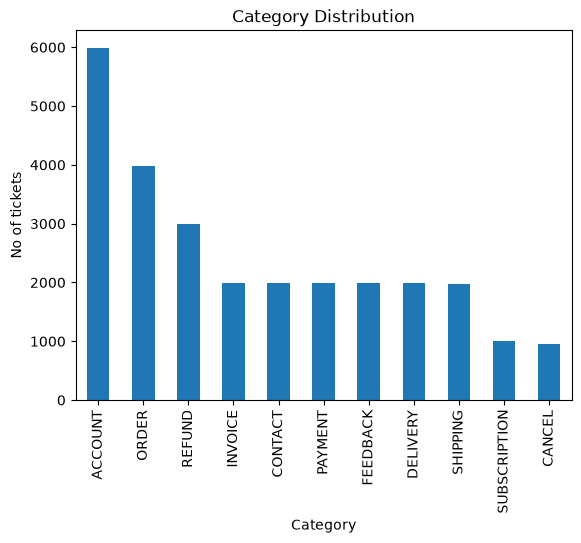

In [384]:
df['category'].value_counts().plot(kind='bar')
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('No of tickets')
plt.show()


In [385]:
df.head(5)

,instruction,category,intent,response
0,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [386]:
df['intent'].value_counts()

intent
check_invoice               1000
complaint                   1000
contact_customer_service    1000
edit_account                1000
switch_account              1000
check_payment_methods        999
contact_human_agent          999
delivery_period              999
get_invoice                  999
newsletter_subscription      999
payment_issue                999
registration_problems        999
cancel_order                 998
place_order                  998
track_refund                 998
change_order                 997
check_refund_policy          997
create_account               997
get_refund                   997
review                       997
set_up_shipping_address      997
delete_account               995
delivery_options             995
recover_password             995
track_order                  995
change_shipping_address      973
check_cancellation_fee       950
Name: count, dtype: int64

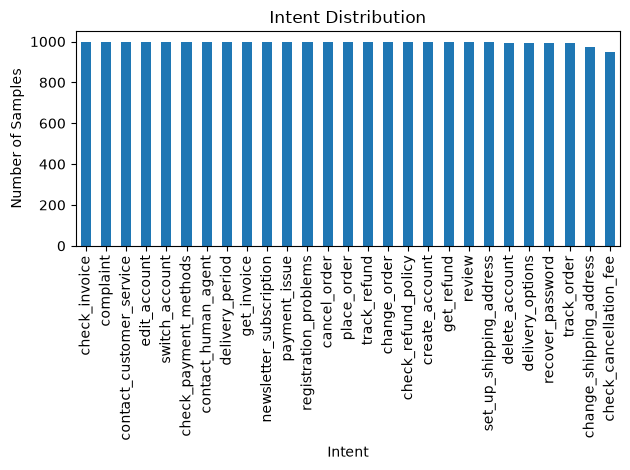

In [387]:
df['intent'].value_counts().plot(kind='bar')
plt.title('Intent Distribution')
plt.xlabel("Intent")
plt.ylabel("Number of Samples")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [388]:
df.head(5)

,instruction,category,intent,response
0,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [389]:
def preprocess(text):
    text = text.lower()

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip() 


    text = re.sub(r"(.)\1{1,}", r"\1", text)
    

    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )


    text = re.sub(
        r"#(\w+)",
        r"\1",
        text
    )


    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )





    words = word_tokenize(text)
    
    words = [word for word in words if word not in stop_words]

    words = [lammmmmetize.lemmatize(word) for word in words]

    text =  "".join(text)
    return text

    

In [390]:
df['question_instruction'] = df['instruction'].apply(preprocess)

In [391]:
df.head(5)

,instruction,category,intent,response,question_instruction
0,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...,question about canceling order order number
1,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...,i have a question about canceling order order...
2,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...,i ned help canceling puchase order number
3,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...,i ned to cancel purchase order number
4,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...,i canot aford this order cancel purchase ord...


In [392]:
df['question_instruction']

0            question about canceling order  order number 
1        i have a question about canceling order  order...
2              i ned help canceling puchase  order number 
3                  i ned to cancel purchase  order number 
4        i canot aford this order  cancel purchase  ord...
                               ...                        
26867    i am waiting for a rebate of  refund amount  d...
26868    how to se if there is anything wrong with my r...
26869    i m waiting for a reimbjrsement of  curency sy...
26870    i don t know what to do to se my reimbursement...
26871    i ned to know if there is anything new on the ...
Name: question_instruction, Length: 26872, dtype: str

In [393]:

X = df['question_instruction'] 
y = df['category']

X_train , X_test , y_train , y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [394]:
print("X:", X.shape)
print("y:", y.shape)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X: (26872,)
y: (26872,)
X_train: (21497,)
X_test: (5375,)
y_train: (21497,)
y_test: (5375,)


In [395]:
y_category_encoder = LabelEncoder()
df['category'] = y_category_encoder.fit_transform(df['category'])

In [396]:
df

,instruction,category,intent,response,question_instruction
0,question about cancelling order {{Order Number}},6,cancel_order,I've understood you have a question regarding ...,question about canceling order order number
1,i have a question about cancelling oorder {{Or...,6,cancel_order,I've been informed that you have a question ab...,i have a question about canceling order order...
2,i need help cancelling puchase {{Order Number}},6,cancel_order,I can sense that you're seeking assistance wit...,i ned help canceling puchase order number
3,I need to cancel purchase {{Order Number}},6,cancel_order,I understood that you need assistance with can...,i ned to cancel purchase order number
4,"I cannot afford this order, cancel purchase {{...",6,cancel_order,I'm sensitive to the fact that you're facing f...,i canot aford this order cancel purchase ord...
...,...,...,...,...,...
26867,I am waiting for a rebate of {{Refund Amount}}...,8,track_refund,Thank you for sharing your situation regarding...,i am waiting for a rebate of refund amount d...
26868,how to see if there is anything wrong with my ...,8,track_refund,Ensuring the accuracy of your restitution is o...,how to se if there is anything wrong with my r...
26869,I'm waiting for a reimbjrsement of {{Currency ...,8,track_refund,"Firstly, I genuinely understand the importance...",i m waiting for a reimbjrsement of curency sy...
26870,I don't know what to do to see my reimbursemen...,8,track_refund,I've understood you're unsure about how to che...,i don t know what to do to se my reimbursement...


In [397]:
df["intent_original"] = df["intent"]
y_intent_encoder = LabelEncoder()

df["intent_encoded"] = y_intent_encoder.fit_transform(df["intent"])

In [398]:

X = df["question_instruction"]
y = df["intent_encoded"]

X_train , X_test , y_train , y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [399]:
print("X:", X.shape)
print("y:", y.shape)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X: (26872,)
y: (26872,)
X_train: (21497,)
X_test: (5375,)
y_train: (21497,)
y_test: (5375,)


In [400]:
df

,instruction,category,intent,response,question_instruction,intent_original,intent_encoded
0,question about cancelling order {{Order Number}},6,cancel_order,I've understood you have a question regarding ...,question about canceling order order number,cancel_order,0
1,i have a question about cancelling oorder {{Or...,6,cancel_order,I've been informed that you have a question ab...,i have a question about canceling order order...,cancel_order,0
2,i need help cancelling puchase {{Order Number}},6,cancel_order,I can sense that you're seeking assistance wit...,i ned help canceling puchase order number,cancel_order,0
3,I need to cancel purchase {{Order Number}},6,cancel_order,I understood that you need assistance with can...,i ned to cancel purchase order number,cancel_order,0
4,"I cannot afford this order, cancel purchase {{...",6,cancel_order,I'm sensitive to the fact that you're facing f...,i canot aford this order cancel purchase ord...,cancel_order,0
...,...,...,...,...,...,...,...
26867,I am waiting for a rebate of {{Refund Amount}}...,8,track_refund,Thank you for sharing your situation regarding...,i am waiting for a rebate of refund amount d...,track_refund,26
26868,how to see if there is anything wrong with my ...,8,track_refund,Ensuring the accuracy of your restitution is o...,how to se if there is anything wrong with my r...,track_refund,26
26869,I'm waiting for a reimbjrsement of {{Currency ...,8,track_refund,"Firstly, I genuinely understand the importance...",i m waiting for a reimbjrsement of curency sy...,track_refund,26
26870,I don't know what to do to see my reimbursemen...,8,track_refund,I've understood you're unsure about how to che...,i don t know what to do to se my reimbursement...,track_refund,26


In [401]:

tf_vector = TfidfVectorizer()


X_train_tf =  tf_vector.fit_transform(X_train)
X_test_tf =  tf_vector.transform(X_test)


In [402]:
print(tf_vector.get_feature_names_out())

print(
    X_train_tf.toarray()
)



['abailable' 'abot' 'abou' ... 'ypur' 'yu' 'yur']
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [403]:
models = {
    'LogisticRegression' : LogisticRegression(
        max_iter=200
    ),
    'DecisionTreeClassifier':DecisionTreeClassifier(
        max_depth=4
    ),
    'RandomForestClassifier' : RandomForestClassifier(),
    'KNeighborsClassifier' : KNeighborsClassifier(
        n_neighbors=3
    ),
    'SVC':SVC()
}   



In [404]:
result = []
for name , model in models.items():

    model.fit(X_train_tf , y_train)
    y_predict = model.predict(X_test_tf)
   


    result.append({
        'Model': name, 
        "Accuracy" : accuracy_score(
            y_test,
            y_predict
        )*100,
        "Precision": precision_score(
            y_test,
            y_predict,
            average='weighted',
            zero_division=0
        )*100,

        "Recall": recall_score(
            y_test,
            y_predict,
            average='weighted',
            zero_division=0
        )*100,

        "F1": f1_score(
            y_test,
            y_predict,
            average='weighted',
            zero_division=0
        )*100,

       
    })

results_df = pd.DataFrame(
        result
)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
)


print(results_df)




                    Model   Accuracy  Precision     Recall         F1
4                     SVC  99.516279  99.522832  99.516279  99.516947
0      LogisticRegression  99.386047  99.396813  99.386047  99.386907
2  RandomForestClassifier  99.181395  99.186361  99.181395  99.181466
3    KNeighborsClassifier  98.400000  98.422707  98.400000  98.403862
1  DecisionTreeClassifier  24.204651  21.688590  24.204651  19.990232


In [405]:
best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

print("Best model:", best_model_name)
print("Model object:", best_model)
print("Type:", type(best_model))

Best model: SVC
Model object: SVC()
Type: <class 'sklearn.svm._classes.SVC'>


In [406]:
print(
    classification_report(
        y_test,
        y_predict,
        zero_division=0
    )*100
)


              precision    recall  f1-score   support

           0       1.00      0.98      0.99       200
           1       0.97      0.99      0.98       199
           2       0.99      1.00      1.00       195
           3       1.00      1.00      1.00       190
           4       0.98      0.99      0.99       200
           5       1.00      1.00      1.00       200
           6       1.00      0.99      1.00       199
           7       1.00      1.00      1.00       200
           8       1.00      0.99      1.00       200
           9       0.99      0.99      0.99       200
          10       0.99      0.99      0.99       199
          11       0.99      1.00      0.99       199
          12       0.99      1.00      1.00       199
          13       1.00      0.99      1.00       200
          14       1.00      1.00      1.00       200
          15       0.99      0.98      0.99       200
          16       0.99      1.00      1.00       199
          17       1.00    

In [433]:
import joblib 


joblib.dump(tf_vector , 'tfidf.pkl')
joblib.dump(y_category_encoder , 'category_encoder.pkl')
joblib.dump(y_intent_encoder , 'intent_encoder.pkl')
joblib.dump(best_model , 'model.pkl')

['model.pkl']

In [408]:
print(type(best_model))
print(type(tf_vector))
print(type(y_category_encoder))
print(type(y_intent_encoder))

<class 'sklearn.svm._classes.SVC'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
<class 'sklearn.preprocessing._label.LabelEncoder'>
<class 'sklearn.preprocessing._label.LabelEncoder'>


In [409]:
df.head(5)

,instruction,category,intent,response,question_instruction,intent_original,intent_encoded
0,question about cancelling order {{Order Number}},6,cancel_order,I've understood you have a question regarding ...,question about canceling order order number,cancel_order,0
1,i have a question about cancelling oorder {{Or...,6,cancel_order,I've been informed that you have a question ab...,i have a question about canceling order order...,cancel_order,0
2,i need help cancelling puchase {{Order Number}},6,cancel_order,I can sense that you're seeking assistance wit...,i ned help canceling puchase order number,cancel_order,0
3,I need to cancel purchase {{Order Number}},6,cancel_order,I understood that you need assistance with can...,i ned to cancel purchase order number,cancel_order,0
4,"I cannot afford this order, cancel purchase {{...",6,cancel_order,I'm sensitive to the fact that you're facing f...,i canot aford this order cancel purchase ord...,cancel_order,0


In [410]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import joblib

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

def build_embeddings(df):

    questions = df["question_instruction"].tolist()

    embeddings = embedding_model.encode(
        questions,
        normalize_embeddings=True
    )


    return embeddings

embeddings = build_embeddings(df)


joblib.dump(embeddings, "embeddings.pkl")
df.to_pickle("reference_data.pkl")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2940.25it/s]


In [432]:

def get_response(
    user_text,
    model,
    tfidf,
    y_intent_encoder,
    df,
    embeddings,
    embedding_model,
    threshold=0.70
):

    #: Clean user input

    cleaned_text = preprocess(user_text)


    # : TF-IDF transformation

    user_tfidf = tfidf.transform([cleaned_text])


    # : Predict category / intent

    prediction = model.predict(user_tfidf)[0]

    predicted_label = y_intent_encoder.inverse_transform([prediction])[0]

    # predicted_label = prediction


    # : Filter dataset

    filtered_indices = df[df["intent"] == predicted_label].index


    # : If nothing found

    if len(filtered_indices) == 0:

        return {
            "response": "I'm not confident I understood your issue. Please provide more details.",
            "intent": predicted_label,
            "similarity": 0
        }


    # : Get embeddings for filtered rows

    filtered_embeddings = embeddings[filtered_indices]


    # : Create embedding for user complaint

    user_embedding = embedding_model.encode(
        [cleaned_text],
        normalize_embeddings=True
    )


    # : Calculate similarity

    similarities = cosine_similarity(
        user_embedding,
        filtered_embeddings,
    )[0]


    # : Find best match

    best_position = similarities.argmax()

    best_score = similarities[best_position]

    best_index = filtered_indices[best_position]


    # : Get matched dataset row

    best_row = df.loc[best_index]


    # : Similarity threshold

    if best_score < threshold:

        return {
            "response": "I'm not confident I understood your issue. Please provide more details.",
            "intent": predicted_label,
            "similarity": float(best_score)
        }


    # : Return actual response
   
    return {
        "response": best_row["response"],
        "intent": predicted_label,
        "similarity": float(best_score)
    }



In [426]:
import joblib 
embeddings = joblib.load("embeddings.pkl")
model = joblib.load("model.pkl")
tfidf = joblib.load("tfidf.pkl")
encoder = joblib.load("../notebook/category_endcoder.pkl")
print(type(model))


<class 'sklearn.svm._classes.SVC'>


In [434]:
result = get_response(
     "I want my product when will my product be delivered",
    model,
    tfidf,
    y_intent_encoder,
    df,
    embeddings,
    embedding_model
)

print(result)

{'response': 'We understand that you are eager to know when your product will arrive. To provide you with an accurate estimate, could you please provide us with the {{Tracking Number}} or {{Order Number}}? With this information, we will be able to check the status of your shipment and give you the expected delivery date. Your patience is greatly appreciated as we work together to ensure a smooth delivery experience for you.', 'intent': 'delivery_period', 'similarity': 0.8021915555000305}


In [431]:
test_queries = [
    "I want to cancel my order",
    "my payment failed",
    "where is my refund",
    "I cannot login",
    "random nonsense xyzabc"
]

for query in test_queries:

    result = get_response(
        query,
        model,
        tfidf,
        y_intent_encoder,
        df,
        embeddings,
        embedding_model
    )

    print("\nUSER:", query)
    print("INTENT:", result["intent"])
    print("SIMILARITY:", result["similarity"])
    print("RESPONSE:", result["response"])


USER: I want to cancel my order
INTENT: cancel_order
SIMILARITY: 0.9084826707839966
RESPONSE: I've understood, you would like to cancel your order associated with the purchase number {{Order Number}}. We apologize for any inconvenience this may have caused. To assist you with the cancellation process, please follow the steps below:

1. Log in to your {{Online Company Portal Info}} using your credentials.
2. Navigate to the '{{Online Order Interaction}}' or '{{Online Order Interaction}}' section.
3. Locate the order with the order number {{Order Number}} and click on it for more details.
4. Look for the '{{Online Order Interaction}}' option associated with the purchase and select it.
5. Follow any additional instructions or prompts provided by the system to confirm the cancellation.

For any further assistance or if you have any questions, please feel free to reach out to our customer support team. They are available during {{Customer Support Hours}} at {{Customer Support Phone Number}